In [177]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, SVG, HTML

# Enable inline plotting for Jupyter
%matplotlib inline

# Paths and model selection
ROOT = Path('/home/daniele/Desktop/tirocinio/energyBANERA-main')
DATA_ROOT = ROOT / 'Data' / 'new_measures' / 'jetson_nano'
PLOT_ROOT = ROOT / 'Plot' / 'new_measures' / 'jetson_nano'
OLD_DATA_ROOT = ROOT / 'Data' / 'Jetson_nano_power_record'
OLD_PLOT_ROOT = ROOT / 'Plot' / 'Jetson_nano_power_record'
STATS_ROOT = DATA_ROOT / 'statistics'

In [ ]:
selected_stem = 'Conv_1_512_3_0' 

In [179]:
model_kind = 'Conv' if selected_stem.startswith('Conv_') else 'Linear'

measurement_dirs = {
    'nograd': DATA_ROOT / ('Conv_3_0_nograd' if model_kind == 'Conv' else 'Linear_nograd'),
    'new': DATA_ROOT / ('Conv_3_0' if model_kind == 'Conv' else 'Linear'),
    'old': OLD_DATA_ROOT / ('Conv_3_0' if model_kind == 'Conv' else 'Linear'),
}

plot_dirs = {
    'nograd': PLOT_ROOT / ('Conv_3_0_nograd' if model_kind == 'Conv' else 'Linear_nograd'),
    'new': PLOT_ROOT / ('Conv_3_0' if model_kind == 'Conv' else 'Linear'),
    'old': OLD_PLOT_ROOT / ('Conv_3_0' if model_kind == 'Conv' else 'Linear'),
}


def load_measurement(mode):
    csv_path = measurement_dirs[mode] / f'{selected_stem}.csv'
    if not csv_path.exists():
        return None, csv_path
    return pd.read_csv(csv_path), csv_path


def trace_file_path(mode):
    return plot_dirs[mode] / f'{selected_stem}.svg'


measurements = {}
for mode in ['nograd', 'new', 'old']:
    frame, csv_path = load_measurement(mode)
    measurements[mode] = {
        'data': frame,
        'csv_path': csv_path,
        'plot_path': trace_file_path(mode),
        'available': frame is not None,
    }

available_modes = [mode for mode in ['nograd', 'new', 'old'] if measurements[mode]['available']]

print(f'Model: {selected_stem}')
print('Available measurements:', ', '.join(mode.title() for mode in available_modes) if available_modes else 'none')


Model: Conv_1_1024_3_0
Available measurements: Nograd, New, Old


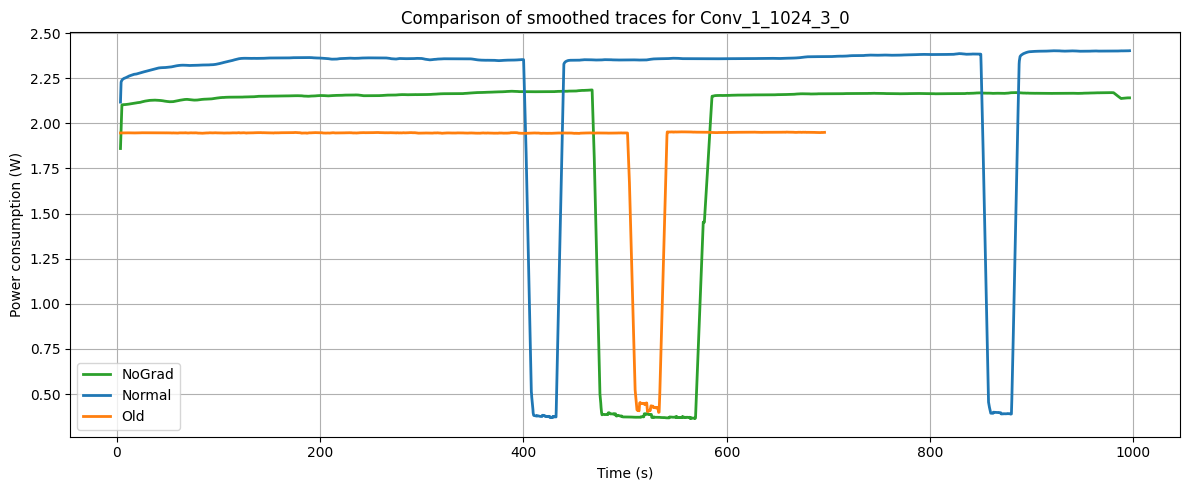

In [180]:
# Compare the smoothed traces from nograd, normal, and old measurements
window_size = 75
comparison = {}

for mode in available_modes:
    payload = measurements[mode]
    df = payload['data'].copy()
    smoothed = df['EVM1 POWER Results (W)'].rolling(window=window_size, center=True).mean().dropna()
    time_sec = (df['Sample'] * 0.1).iloc[smoothed.index]
    comparison[mode] = {
        'time_sec': time_sec,
        'smoothed': smoothed,
    }

if comparison:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = {'nograd': 'tab:green', 'new': 'tab:blue', 'old': 'tab:orange'}
    labels = {'nograd': 'NoGrad', 'new': 'Normal', 'old': 'Old'}

    for mode in ['nograd', 'new', 'old']:
        if mode not in comparison:
            continue
        ax.plot(
            comparison[mode]['time_sec'],
            comparison[mode]['smoothed'],
            label=labels[mode],
            linewidth=2.0,
            color=colors[mode],
        )

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Power consumption (W)')
    ax.set_title(f'Comparison of smoothed traces for {selected_stem}')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f'No available measurements found for {selected_stem}.')


In [181]:
# Show only the available summary lines for the current file
import sys

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import data_processing as dp


def format_layer_label(stem):
    parts = stem.split('_')
    if stem.startswith('Conv_') and len(parts) >= 5:
        return f"Conv({parts[1]}, {parts[2]}, {parts[3]}, {parts[4]})"
    if stem.startswith('Linear_') and len(parts) >= 3:
        return f"Linear({parts[1]}, {parts[2]})"
    return stem


def normalize_text(value):
    return ''.join(str(value).split()).lower()


def find_stats_row(stats_file, label):
    workbook = pd.ExcelFile(stats_file)
    normalized_label = normalize_text(label)

    for sheet_name in workbook.sheet_names:
        stats_df = pd.read_excel(stats_file, sheet_name=sheet_name)
        label_column = None
        for candidate in ['Layer (params)', 'Layer']:
            if candidate in stats_df.columns:
                label_column = candidate
                break

        if label_column is None:
            continue

        normalized_series = stats_df[label_column].astype(str).map(normalize_text)
        matching_rows = stats_df[normalized_series == normalized_label]
        if not matching_rows.empty:
            return matching_rows.iloc[0].to_dict()

    return None


def stats_file_for_mode(mode):
    if model_kind.lower() == 'conv':
        if mode == 'old':
            return ROOT / 'Data' / 'new_measures' / 'jetson_nano' / 'statistics' / 'conv_power_report.xlsx'
        if mode == 'nograd':
            return ROOT / 'Data' / 'new_measures' / 'jetson_nano' / 'statistics' / 'measures_statistics_conv_3_0_nograd.xlsx'
        return ROOT / 'Data' / 'new_measures' / 'jetson_nano' / 'statistics' / 'measures_statistics_conv_3_0.xlsx'

    if mode == 'old':
        return ROOT / 'Data' / 'new_measures' / 'jetson_nano' / 'statistics' / 'linear_power_report.xlsx'
    if mode == 'nograd':
        return ROOT / 'Data' / 'new_measures' / 'jetson_nano' / 'statistics' / 'measures_statistics_linear_nograd.xlsx'
    return ROOT / 'Data' / 'new_measures' / 'jetson_nano' / 'statistics' / 'measures_statistics_linear.xlsx'


def stats_from_csv(mode):
    df = measurements[mode]['data'].copy()
    results = dp.get_average_power(df)
    return {
        'Power mean (W)': results['power_avg_W'],
        'Power variance (W^2)': results['power_var_W2'],
        'Energy mean (J)': results['energy_avg_J'],
        'Energy variance (J^2)': results['energy_var_J2'],
    }


selected_label = format_layer_label(selected_stem)
summary_order = ['nograd', 'new', 'old']
summary_labels = {'nograd': 'NoGrad', 'new': 'Normal', 'old': 'Old'}
available_modes = [mode for mode in summary_order if measurements[mode]['available']]
rows = []

for mode in available_modes:
    stats_row = find_stats_row(stats_file_for_mode(mode), selected_label)
    if stats_row is None:
        stats_row = stats_from_csv(mode)

    rows.append({
        'Measurement': summary_labels[mode],
        'Power mean (W)': stats_row.get('Power mean (W)'),
        'Power variance (W^2)': stats_row.get('Power variance (W^2)', stats_row.get('Power variance (W²)')),
        'Energy mean (J)': stats_row.get('Energy mean (J)'),
        'Energy variance (J^2)': stats_row.get('Energy variance (J^2)', stats_row.get('Energy variance (J²)')),
    })

summary_df = pd.DataFrame(rows)
summary_df['Measurement'] = pd.Categorical(summary_df['Measurement'], categories=['NoGrad', 'Normal', 'Old'], ordered=True)
summary_df = summary_df.sort_values('Measurement').reset_index(drop=True)
display(summary_df)


,Measurement,Power mean (W),Power variance (W^2),Energy mean (J),Energy variance (J^2)
0,NoGrad,1.742742,1.392834e-06,0.007833,2.909380e-07
1,Normal,1.896301,2.361953e-04,0.007064,1.012494e-05
2,Old,1.753418,3.724914e-07,0.007889,2.911639e-07
